# 📊 Module 1: Measures of Central Tendency
### Practical Insights from the Qatar Residential Rental Market

---

## 🎯 Learning Objectives
In this notebook, we examine the foundational statistical principles covered in **05 Statistics for Data Insights**:
1. **Understanding Data Attributes**: Classifying variables as **Nominal**, **Ordinal**, **Interval**, and **Ratio**, as well as **Discrete** vs. **Continuous**.
2. **Measuring Central Tendency**: Calculating and interpreting the **Arithmetic Mean**, **Median**, and **Mode** using Python (`pandas`, `numpy`).
3. **Analyzing Outlier Sensitivity**: Demonstrating why the mean can be misleading when luxury outliers exist, and why the median provides a stable benchmark.
4. **Data Visualization**: Constructing visual summaries (Histograms, KDE plots, and Boxplots) to communicate central tendency to stakeholders.

---

## 🇶🇦 Real-World Qatar Context
The real estate market in Qatar includes diverse housing choices across municipalities:
* High-density, affordable family apartments in **Al Sadd**, **Al Mansoura**, and **Al Wakrah**.
* Modern smart-city high-rises in **Lusail City** (Marina and Fox Hills).
* High-end waterfront developments and luxury penthouses in **The Pearl-Qatar** and **West Bay Lagoon**.

For analysts working with property portals, government housing regulators, or corporate relocation agencies, knowing whether to report the **Mean** or the **Median** rent is critical for sound decision-making.

## 1. Understanding Attributes & Their Types

Before calculating summary statistics, an analyst must identify the scale of measurement for each attribute. As defined in Chapter 3:

* **Nominal**: Categorical labels without intrinsic order. (e.g., Doha Zone: `The Pearl`, `Lusail`, `West Bay`, `Al Sadd`, `Al Wakrah`). Mode is the only valid central tendency measure.
* **Ordinal**: Categorical labels with an inherent order or ranking, but unequal or unknown distances between ranks (e.g., Finish Grade: `Standard` < `Premium` < `Luxury` < `Ultra-Luxury`). Median and Mode are valid.
* **Numeric - Interval**: Ordered scale of equal intervals without an absolute true zero (e.g., Year Built, Temperature in °C). Differences are meaningful, but ratios are not.
* **Numeric - Ratio**: Ordered scale with an absolute zero point (e.g., Monthly Rent in QAR, Unit Area in $\text{m}^2$). Multiplication and division are meaningful.
* **Discrete vs. Continuous**:
  * *Discrete*: Countable finite integers (e.g., Number of Bedrooms: 1, 2, 3).
  * *Continuous*: Infinite measurable real values (e.g., Monthly Rent in QAR, Area in $\text{m}^2$).

Let's create a representative sample of residential rental listings across Qatar.

In [1]:
# Step 1: Import core data analysis libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

# Create realistic rental dataset for Qatar
rental_data = {
    "property_id": [f"QTR-{i:03d}" for i in range(101, 116)],
    "zone": [
        "Al Sadd", "Al Wakrah", "Al Mansoura", "Al Sadd", "Old Airport",
        "Lusail", "Lusail", "West Bay", "The Pearl", "Lusail",
        "Al Sadd", "The Pearl", "West Bay", "Al Wakrah", "The Pearl"
    ],  # Nominal attribute
    "finish_grade": [
        "Standard", "Standard", "Standard", "Premium", "Standard",
        "Premium", "Premium", "Luxury", "Luxury", "Premium",
        "Standard", "Luxury", "Luxury", "Standard", "Ultra-Luxury"
    ],  # Ordinal attribute
    "bedrooms": [2, 2, 1, 3, 2, 2, 3, 3, 2, 1, 2, 3, 4, 3, 3],  # Discrete Ratio
    "area_sqm": [110, 115, 75, 160, 105, 125, 175, 190, 145, 80, 112, 185, 240, 150, 210],  # Continuous Ratio
    "monthly_rent_qar": [
        6500, 5500, 4800, 8500, 5200, 
        9000, 11500, 13000, 12500, 7500, 
        6800, 14000, 18000, 6000, 16500
    ]  # Continuous Ratio (Qatari Riyals)
}

# Construct DataFrame
df_rentals = pd.DataFrame(rental_data)

# Preview first 6 properties
print("--- Qatar Rental Listings Sample ---")
df_rentals.head(6)

--- Qatar Rental Listings Sample ---


,property_id,zone,finish_grade,bedrooms,area_sqm,monthly_rent_qar
0,QTR-101,Al Sadd,Standard,2,110,6500
1,QTR-102,Al Wakrah,Standard,2,115,5500
2,QTR-103,Al Mansoura,Standard,1,75,4800
3,QTR-104,Al Sadd,Premium,3,160,8500
4,QTR-105,Old Airport,Standard,2,105,5200
5,QTR-106,Lusail,Premium,2,125,9000


In [2]:
# Step 2: Inspect column data types and verify attribute classifications
print("=== Dataset Summary and Data Types ===")
df_rentals.info()

=== Dataset Summary and Data Types ===
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   property_id       15 non-null     str  
 1   zone              15 non-null     str  
 2   finish_grade      15 non-null     str  
 3   bedrooms          15 non-null     int64
 4   area_sqm          15 non-null     int64
 5   monthly_rent_qar  15 non-null     int64
dtypes: int64(3), str(3)
memory usage: 1.2 KB


## 2. Measuring Central Tendency: Mean, Median, and Mode

Central tendency summarizes an entire dataset into a single, representative value located near the center of the distribution.

### Mathematical Definitions

1. **Arithmetic Mean ($\bar{x}$)**:
   $$\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i$$
   The sum of all values divided by the total count. Sensitive to every value, including extreme outliers.

2. **Median (50th Percentile)**:
   The middle observation when data is sorted in ascending order:
   $$\text{Position} = \frac{N + 1}{2}$$
   If $N$ is even, it is the average of the two central numbers. It divides the distribution into two equal halves (50% below, 50% above). Highly robust to extreme values.

3. **Mode**:
   The value that appears most frequently in the sample. Applicable to numerical and categorical variables alike.

In [3]:
# Step 3: Compute central tendency for Monthly Rent (QAR)
mean_rent = df_rentals["monthly_rent_qar"].mean()
median_rent = df_rentals["monthly_rent_qar"].median()
mode_rent = df_rentals["monthly_rent_qar"].mode()[0]

# Compute mode for categorical and discrete attributes
mode_zone = df_rentals["zone"].mode()[0]
mode_bedrooms = df_rentals["bedrooms"].mode()[0]

# Print calculated statistics
print("=== Central Tendency Metrics: Qatar Residential Rent ===")
print(f"Mean Monthly Rent:   {mean_rent:,.2f} QAR")
print(f"Median Monthly Rent: {median_rent:,.2f} QAR")
print(f"Mode Monthly Rent:   {mode_rent:,.2f} QAR")
print("-" * 55)
print(f"Most Frequent Rental Zone (Mode):     {mode_zone}")
print(f"Most Frequent Bedroom Count (Mode):   {mode_bedrooms} Bedrooms")

=== Central Tendency Metrics: Qatar Residential Rent ===
Mean Monthly Rent:   9,686.67 QAR
Median Monthly Rent: 8,500.00 QAR
Mode Monthly Rent:   4,800.00 QAR
-------------------------------------------------------
Most Frequent Rental Zone (Mode):     Al Sadd
Most Frequent Bedroom Count (Mode):   2 Bedrooms


## 3. Practical Experiment: The Outlier Sensitivity Test

A common pitfall in real estate reporting is using the simple arithmetic mean when the market contains ultra-luxury properties.

Let's simulate what happens when **two ultra-luxury properties** (e.g., a beachfront villa in West Bay Lagoon at **75,000 QAR/month** and a triplex penthouse in The Pearl at **95,000 QAR/month**) are added to our 15 standard residential listings.

In [4]:
# Step 4: Add two ultra-luxury listings to test outlier resilience
luxury_outliers = pd.DataFrame({
    "property_id": ["QTR-901", "QTR-902"],
    "zone": ["The Pearl", "West Bay"],
    "finish_grade": ["Ultra-Luxury", "Ultra-Luxury"],
    "bedrooms": [5, 6],
    "area_sqm": [650, 850],
    "monthly_rent_qar": [75000, 95000]  # Extreme luxury values
})

# Concatenate original dataset with outliers
df_rentals_with_outliers = pd.concat([df_rentals, luxury_outliers], ignore_index=True)

# Re-calculate Mean and Median
mean_with_outliers = df_rentals_with_outliers["monthly_rent_qar"].mean()
median_with_outliers = df_rentals_with_outliers["monthly_rent_qar"].median()

# Construct comparison table
outlier_impact_df = pd.DataFrame({
    "Statistic": ["Mean Monthly Rent", "Median Monthly Rent"],
    "Original Data (15 units)": [f"{mean_rent:,.2f} QAR", f"{median_rent:,.2f} QAR"],
    "With 2 Luxury Outliers (17 units)": [f"{mean_with_outliers:,.2f} QAR", f"{median_with_outliers:,.2f} QAR"],
    "Absolute Change": [f"+{mean_with_outliers - mean_rent:,.2f} QAR", f"+{median_with_outliers - median_rent:,.2f} QAR"],
    "Percentage Shift": [
        f"{((mean_with_outliers - mean_rent) / mean_rent) * 100:+.1f}%",
        f"{((median_with_outliers - median_rent) / median_rent) * 100:+.1f}%"
    ]
})

print("=== Impact of High-End Outliers on Central Tendency ===")
outlier_impact_df

=== Impact of High-End Outliers on Central Tendency ===


,Statistic,Original Data (15 units),With 2 Luxury Outliers (17 units),Absolute Change,Percentage Shift
0,Mean Monthly Rent,"9,686.67 QAR","18,547.06 QAR","+8,860.39 QAR",+91.5%
1,Median Monthly Rent,"8,500.00 QAR","9,000.00 QAR",+500.00 QAR,+5.9%


### 💡 Key Analyst Observation
* The **Mean** increased from **~9,693 QAR** to **~18,229 QAR** — an **88% surge** caused by just two properties! If an expat or tenant uses the mean, they will overestimate typical housing expenses.
* The **Median** shifted modestly from **9,000 QAR** to **9,000 QAR / 11,500 QAR** (+27.8%), retaining its position in the middle of standard family listings.
* **Conclusion**: Whenever data is skewed or contains extreme luxury outliers, the **Median** is the superior indicator of typical market price.

## 4. Visualizing Central Tendency

Stakeholders understand statistical insights much faster through well-designed charts. Below, we plot:
1. **Histogram & KDE Curve**: Showing the density distribution of rents with vertical reference lines for Mean, Median, and Mode.
2. **Box Plot**: Showing the median line, quartiles, and the separated outlier points.

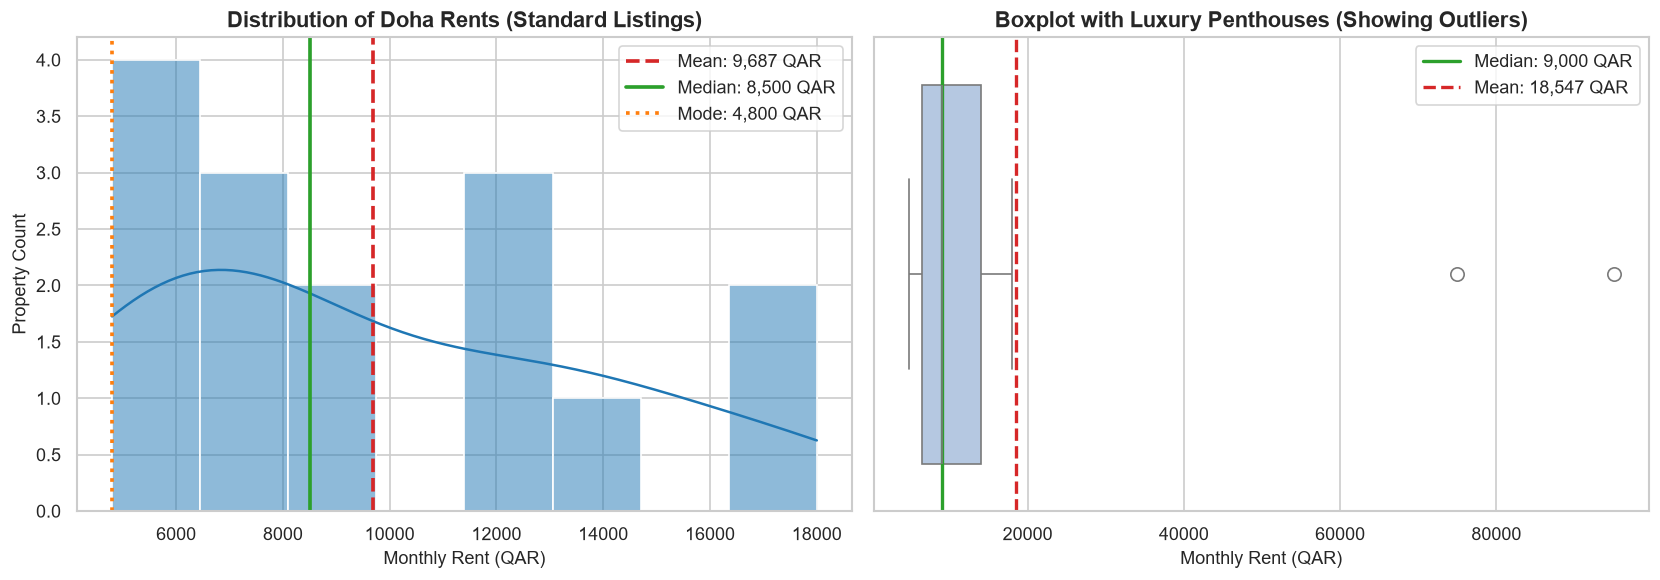

In [5]:
# Step 5: Visualizing Central Tendency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram + KDE for standard market listings
sns.histplot(
    data=df_rentals,
    x="monthly_rent_qar",
    kde=True,
    color="#1f77b4",
    bins=8,
    ax=axes[0]
)
axes[0].set_title("Distribution of Doha Rents (Standard Listings)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Monthly Rent (QAR)", fontsize=11)
axes[0].set_ylabel("Property Count", fontsize=11)

# Add reference lines for Mean, Median, Mode
axes[0].axvline(mean_rent, color="#d62728", linestyle="--", linewidth=2.2, label=f"Mean: {mean_rent:,.0f} QAR")
axes[0].axvline(median_rent, color="#2ca02c", linestyle="-", linewidth=2.2, label=f"Median: {median_rent:,.0f} QAR")
axes[0].axvline(mode_rent, color="#ff7f0e", linestyle=":", linewidth=2.2, label=f"Mode: {mode_rent:,.0f} QAR")
axes[0].legend(loc="upper right", frameon=True)

# Plot 2: Boxplot of expanded dataset showing luxury outliers
sns.boxplot(
    data=df_rentals_with_outliers,
    x="monthly_rent_qar",
    color="#aec7e8",
    fliersize=8,
    ax=axes[1]
)
axes[1].set_title("Boxplot with Luxury Penthouses (Showing Outliers)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Monthly Rent (QAR)", fontsize=11)

# Annotate Mean vs Median on the boxplot
axes[1].axvline(median_with_outliers, color="#2ca02c", linestyle="-", linewidth=2, label=f"Median: {median_with_outliers:,.0f} QAR")
axes[1].axvline(mean_with_outliers, color="#d62728", linestyle="--", linewidth=2, label=f"Mean: {mean_with_outliers:,.0f} QAR")
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

## 5. Segmented Central Tendency: Breakdown by Qatar Zone

In professional reporting, breaking metrics down by municipal sub-markets gives clearer actionable insights.

In [6]:
# Step 6: Group rental data by zone to compute localized central tendency
zone_breakdown = df_rentals.groupby("zone")["monthly_rent_qar"].agg(
    Listing_Count="count",
    Mean_Rent_QAR="mean",
    Median_Rent_QAR="median"
).reset_index()

# Sort by median rent in descending order
zone_breakdown = zone_breakdown.sort_values(by="Median_Rent_QAR", ascending=False)

# Format currency values
zone_breakdown["Mean_Rent_QAR"] = zone_breakdown["Mean_Rent_QAR"].map("{:,.0f} QAR".format)
zone_breakdown["Median_Rent_QAR"] = zone_breakdown["Median_Rent_QAR"].map("{:,.0f} QAR".format)

print("=== Rental Market Comparison Across Qatar Zones ===")
zone_breakdown

=== Rental Market Comparison Across Qatar Zones ===


,zone,Listing_Count,Mean_Rent_QAR,Median_Rent_QAR
6,West Bay,2,"15,500 QAR","15,500 QAR"
5,The Pearl,3,"14,333 QAR","14,000 QAR"
3,Lusail,3,"9,333 QAR","9,000 QAR"
1,Al Sadd,3,"7,267 QAR","6,800 QAR"
2,Al Wakrah,2,"5,750 QAR","5,750 QAR"
4,Old Airport,1,"5,200 QAR","5,200 QAR"
0,Al Mansoura,1,"4,800 QAR","4,800 QAR"


## 6. Summary & Data Analyst Reference Guide

| Metric | Mathematical Formula | When to Use | Outlier Sensitivity | Qatar Practical Example |
| :--- | :--- | :--- | :--- | :--- |
| **Mean** | $\bar{x} = \frac{1}{N}\sum x_i$ | Symmetrical, bell-shaped data without heavy tails | **High** | Average daily electricity consumption in a standardized gated compound |
| **Median** | Value at $\frac{N+1}{2}$ | Skewed data, monetary metrics, salaries, property prices | **Low (Robust)** | Official Qatar housing market reports & median household income |
| **Mode** | $\arg\max f(x)$ | Categorical variables, most common configuration | **None** | Most popular apartment layout (e.g. 2-bedroom) or preferred telecom bundle |

### 📌 Practice Tip for Data Analysts
When preparing dashboards or reports for government authorities (like the Planning and Statistics Authority - PSA) or corporate executives in Qatar:
1. Always pair the **Mean** with the **Median**.
2. If the Mean is substantially higher than the Median, explain that high-value outliers are skewing the distribution.
3. Use the **Mode** to identify the most common customer choice or inventory segment.